# FDTDX Tutorial: A Plane Wave Hitting a Sphere and a Cylinder

This notebook walks through a small, self-contained [fdtdx](https://fdtdx.readthedocs.io/en/latest/) simulation:
a uniform plane wave travels through vacuum and hits two dielectric scattering
objects placed side by side — a **sphere** and a **cylinder**. The simulation
volume is surrounded by **Perfectly Matched Layer (PML) absorbing boundaries
on all six sides**, so there are no reflections from the edges of the box.

Along the way we will use two different visualization helpers and compare
what they actually show:

- **`fdtdx.plot_setup`** — draws the *bounding box* of every object (i.e. the
  rectangular region defined by `partial_real_shape`/`partial_real_position`).
  It has no idea whether an object is a sphere, a cube or a cylinder — it
  just draws a rectangle.
- **`fdtdx.plot_material`** — renders the *actual voxelized material
  distribution* (the permittivity that the FDTD solver will use), so a
  sphere really looks round and a cylinder really looks like a cylinder.

By the end of the notebook the difference between the two will be obvious:
in `plot_setup` the sphere and the cylinder look like two identical squares,
while in `plot_material` one is a filled circle and the other is a rod that
is clearly extruded along one axis.

**Requirements:** `pip install fdtdx`

In [68]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pytreeclass as tc
from IPython.display import Video

import fdtdx

%matplotlib inline

## 1. Simulation configuration

`fdtdx.SimulationConfig` defines the duration of the simulation, the spatial
resolution (grid spacing), the numerical precision and the Courant stability
factor. We also create a JAX random key, which fdtdx requires even for a
fully deterministic simulation like this one.

In [70]:
# JAX random key
key = jax.random.PRNGKey(seed=42)

# List of all simulation objects (volume, boundaries, source, scatterers, detectors, ...)
object_list = []

config = fdtdx.SimulationConfig(
    time=200e-15,          # total simulated time: 200 fs
    grid=fdtdx.UniformGrid(spacing=100e-9),     # grid spacing: 100 nm
    dtype=jnp.float32,
    courant_factor=0.99,
)

## 2. Simulation volume

The `SimulationVolume` defines the background (non-PML) region of the
simulation and its background material — here just vacuum
(`permittivity=1.0`, `permeability=1.0`).

In [33]:
volume = fdtdx.SimulationVolume(
    partial_real_shape=(14e-6, 10e-6, 12e-6),  # size in meters (x, y, z)
    material=fdtdx.Material(
        permittivity=1.0,
        permeability=1.0,
    ),
)
object_list.append(volume)

# Constraints connect objects to each other / to the volume. We build this
# list incrementally as we add more objects below.
constraints = []

## 3. Boundary conditions — PML on all six sides

`fdtdx.BoundaryConfig.from_uniform_bound` is a shortcut that creates the same
boundary type on all six faces of the simulation volume, instead of having
to specify each face manually. We use absorbing PML boundaries everywhere
with a thickness of 10 grid cells (1 µm at our resolution), which is enough
to strongly suppress reflections back into the simulation domain.

In [36]:
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=10, boundary_type="pml")
bound_dict, bound_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)

object_list.extend(bound_dict.values())
constraints.extend(bound_constraints)

## 4. Plane wave source

`fdtdx.UniformPlaneSource` emits a spatially uniform ("plane") wave — as
opposed to `fdtdx.GaussianPlaneSource`, which has a Gaussian spatial
envelope. We place it near the top of the volume, propagating downward
(`direction="-"`) along z, and polarize the electric field along x.

The source is made slightly smaller than the full x/y extent of the volume
(`14e-6 -> 12e-6`, `10e-6 -> 8e-6`) so that its edges do not sit directly on
top of the PML — this avoids strong edge diffraction and keeps the wavefront
that reaches our scatterers clean and plane-like.

In [39]:
source = fdtdx.UniformPlaneSource(
    partial_grid_shape=(None, None, 1),      # a single-cell-thick sheet in z
    partial_real_shape=(12e-6, 8e-6, None),  # finite aperture in x and y
    fixed_E_polarization_vector=(1, 0, 0),   # Ex-polarized
    wave_character=fdtdx.WaveCharacter(wavelength=1.550e-6),
    direction="-",                           # propagates toward -z
    name="Source",
)
object_list.append(source)

constraints.append(
    source.place_relative_to(
        volume,
        axes=(0, 1, 2),
        own_positions=(0, 0, 1),
        other_positions=(0, 0, 1),
        margins=(0, 0, -1.5e-6),  # inset 1.5 µm from the top of the volume
    )
)

## 5. The scattering objects: a sphere and a cylinder

Both objects are made of the same dielectric material
(`permittivity=4.0`, i.e. refractive index n = 2) so that any visual
difference we see later comes purely from their *geometry*, not from a
different material.

- **`fdtdx.Sphere`** only needs a `radius` — its bounding box
  (`partial_real_shape`) is derived automatically as `(2r, 2r, 2r)`.
- **`fdtdx.Cylinder`** needs a `radius` and an `axis` (0 = x, 1 = y, 2 = z),
  which is the direction along which it extends. We pick `axis=1` (the
  y-axis), i.e. the cylinder lies on its side, perpendicular to the
  direction the plane wave travels (z) and perpendicular to the
  sphere-to-cylinder line (x). Its cross-section (a circle of the given
  radius) therefore lives in the x-z plane, and we stretch it across the
  *entire* y-extent of the volume with `same_size(volume, axes=(1,))` so it
  behaves like an infinitely long rod.

For both objects, note that `Sphere`/`Cylinder` take a `materials` dictionary
plus a `material_name` key (rather than a single `material=...` argument, as
`UniformMaterialObject` does) — this is what lets these "static multi
material" objects support more complex material distributions in general.

In [42]:
dielectric = fdtdx.Material(permittivity=4.0)  # n = 2, used for both objects

sphere = fdtdx.Sphere(
    radius=1.2e-6,
    materials={"dielectric": dielectric},
    material_name="dielectric",
    name="Sphere",
    color=fdtdx.colors.PINK,
)
object_list.append(sphere)
constraints.append(
    sphere.place_relative_to(
        volume,
        axes=(0, 1, 2),
        own_positions=(0, 0, 0),
        other_positions=(0, 0, 0),
        margins=(-3.0e-6, 0.0, 0.0),  # shift 3 µm in -x from the volume center
    )
)

cylinder = fdtdx.Cylinder(
    radius=1.2e-6,
    axis=1,  # extends along y
    materials={"dielectric": dielectric},
    material_name="dielectric",
    name="Cylinder",
)
object_list.append(cylinder)
constraints.append(
    cylinder.place_relative_to(
        volume,
        axes=(0, 1, 2),
        own_positions=(0, 0, 0),
        other_positions=(0, 0, 0),
        margins=(3.0e-6, 0.0, 0.0),  # shift 3 µm in +x from the volume center
    )
)
constraints.append(
    cylinder.same_size(volume, axes=(1,))  # stretch the cylinder across all of y
)

## 6. Detector for a video of the scattering process

An `fdtdx.EnergyDetector` records the electromagnetic energy at chosen time
steps. We use `as_slices=True`, which is a memory optimization that only
stores the 2D slices actually needed for plotting/video instead of the full
3D volume at every recorded step.

In [45]:
video_energy_detector = fdtdx.EnergyDetector(
    name="Video",
    as_slices=True,
    switch=fdtdx.OnOffSwitch(interval=3),  # record every 3rd time step
    exact_interpolation=True,
    num_video_workers=8,
)
object_list.append(video_energy_detector)
constraints.extend(video_energy_detector.same_position_and_size(volume))

## 7. Resolve the constraints

`fdtdx.place_objects` takes the list of objects and the list of constraints
between them and resolves everything into concrete grid positions/shapes.
This is also where the actual voxel grids (permittivity, fields, ...) get
allocated.

In [48]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

print(tc.tree_summary(arrays, depth=1))

┌───────────────────────────┬──────────────────┬──────────┬────────┐
│Name                       │Type              │Count     │Size    │
├───────────────────────────┼──────────────────┼──────────┼────────┤
│.fields                    │FieldState        │13,504,000│51.51MB │
├───────────────────────────┼──────────────────┼──────────┼────────┤
│.inv_permittivities        │f32[1,140,100,120]│1,680,000 │6.41MB  │
├───────────────────────────┼──────────────────┼──────────┼────────┤
│.inv_permeabilities        │float             │1         │        │
├───────────────────────────┼──────────────────┼──────────┼────────┤
│.detector_states           │dict              │14,980,000│57.14MB │
├───────────────────────────┼──────────────────┼──────────┼────────┤
│.recording_state           │NoneType          │          │        │
├───────────────────────────┼──────────────────┼──────────┼────────┤
│.electric_conductivity     │NoneType          │          │        │
├───────────────────────────┼─────

## 8. `plot_setup` — bounding boxes only

Let's look at the resolved simulation scene with `fdtdx.plot_setup`. It
shows three cross-sections (XY, XZ, YZ) of the simulation volume with every
object drawn as a colored **rectangle** — its bounding box.

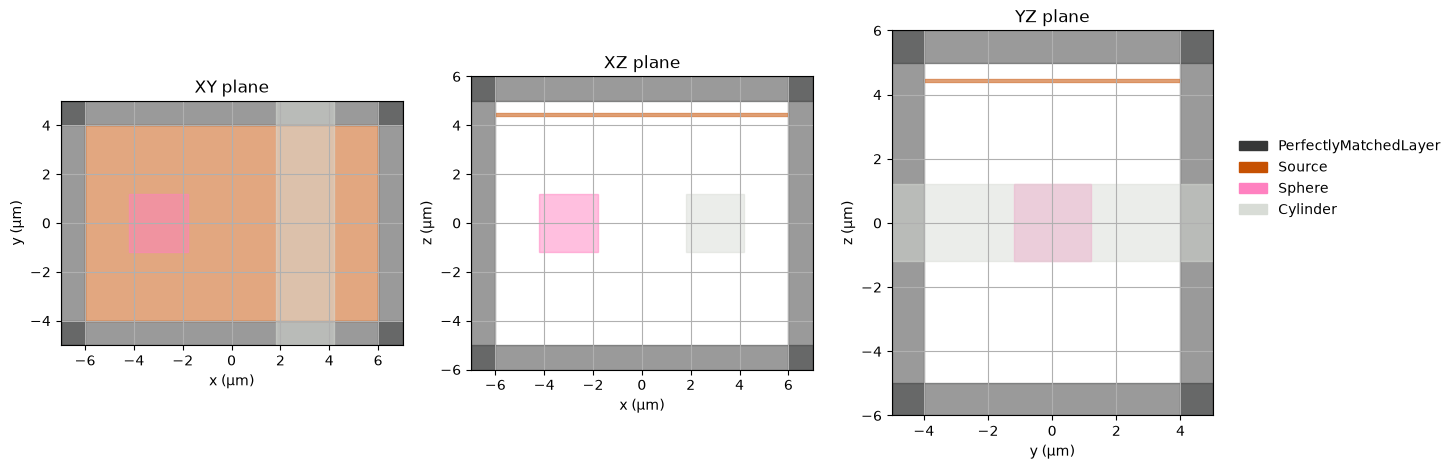

In [51]:
fig = fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[video_energy_detector],
)
plt.show()

Notice that the sphere and the cylinder appear as **two identical-looking
squares** of the same size in every plane. `plot_setup` only ever knows
about `partial_real_shape` / `partial_real_position` — the object's bounding
box — so a perfect sphere and a cube-shaped object would be drawn exactly
the same way. It is very useful for a quick sanity check of *where* things
are and whether objects overlap, but it tells you nothing about the actual
shape of an object.

## 9. `plot_material` — the real, voxelized geometry

Now let's look at `fdtdx.plot_material`, which plots the actual permittivity
that was written into the simulation grid — the thing the FDTD solver will
actually see and scatter off of. We pass `positions=(0.0, 0.0, 0.0)` to slice
through the center of the volume in all three directions (the default).

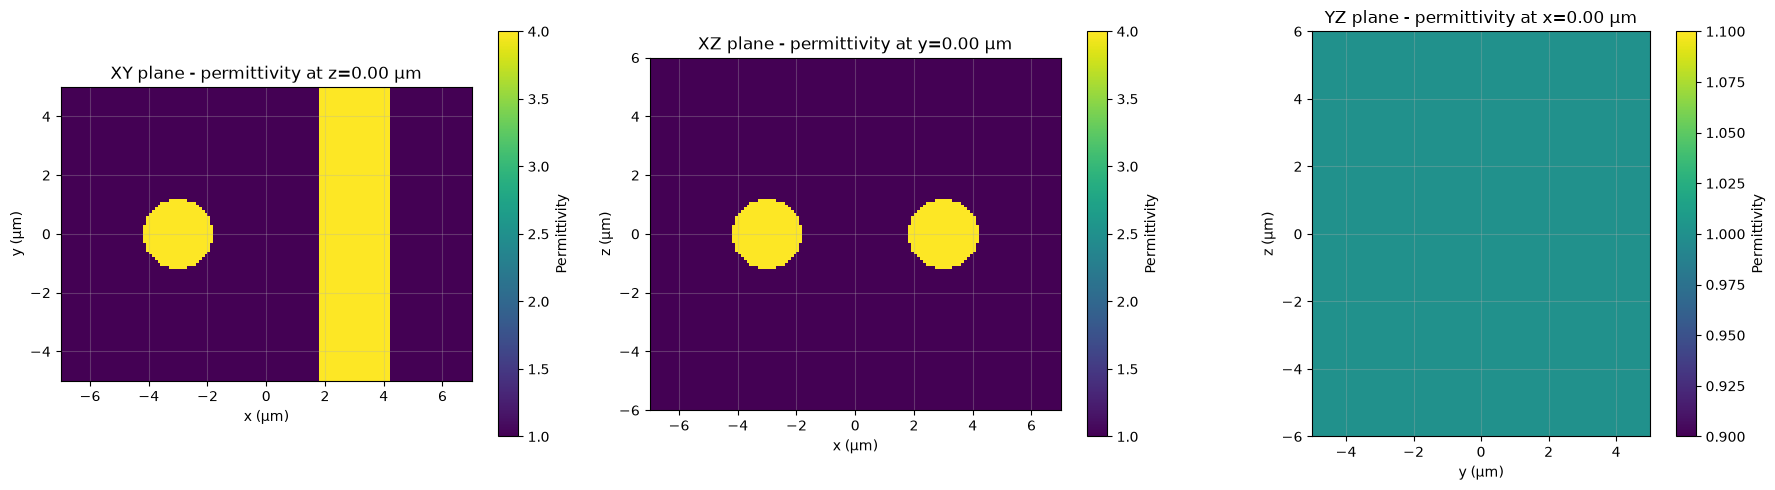

In [55]:
fig = fdtdx.plot_material(
    config=config,
    arrays=arrays,
    positions=(0.0, 0.0, 0.0),
)
plt.show()

This time the two objects look completely different, exactly as they should:

- The **sphere** shows up as a filled **circle** in *all three* cross-sections
  (XY, XZ and YZ) — the signature of a true 3D sphere.
- The **cylinder** shows up as a filled circle only in the **XZ plane**
  (perpendicular to its `axis=1` extrusion direction), but as a **rectangular
  band spanning the full y-range** in the XY and YZ planes — the signature of
  a shape that is extruded ("infinitely long") along y.

This is the key difference between the two plotting functions:
`plot_setup` only ever draws bounding boxes and can't distinguish a sphere
from a cube, while `plot_material` draws the material that was actually
discretized onto the Yee grid — a sphere really looks round, and a cylinder
really looks like a rod.

## 10. Running the simulation

Running an fdtdx simulation is a two-step process:

1. `fdtdx.apply_params` applies any (here: none) design parameters and
   performs some pre-computation.
2. `fdtdx.run_fdtd` performs the actual FDTD time-stepping loop.

We wrap both in a function and JIT-compile it with `jax.jit` for speed. We
use `.lower().compile()` explicitly only so that we can time the
compilation separately from the actual simulation run — feel free to just
use `jax.jit(sim_fn)` directly in your own scripts.

In [59]:
def sim_fn(
    params: fdtdx.ParameterContainer,
    arrays: fdtdx.ArrayContainer,
    key: jax.Array,
):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)

    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
    )
    _, arrays = final_state
    return arrays

In [61]:
start_time = time.time()
jitted_sim_fn = jax.jit(sim_fn).lower(params, arrays, key).compile()
print(f"Compilation time: {time.time() - start_time:.2f} seconds")

Compilation time: 0.42 seconds


In [63]:
start_time = time.time()
new_arrays = jitted_sim_fn(params, arrays, subkey)
print(f"Simulation runtime: {time.time() - start_time:.2f} seconds")

FDTD (checkpointed):   0%|                           | 0/1049 [00:00<?, ?step/s]

Simulation runtime: 9.50 seconds


## 11. Visualizing the result

Finally, let's turn the recorded energy detector states into a video of the
plane wave traveling through the domain, wrapping around the sphere and
scattering off the cylinder.

In [66]:
video_path = objects["Video"].draw_plot(new_arrays.detector_states["Video"])
Video(list(video_path.values())[0], embed=True, width=720)